# Convert text output from SIM to netcdf for easier data analysis

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cmocean.cm as cmo

Define path to experiment folder

In [2]:
path = "/aos/home/jrieck/src/SIM/"

Define parameters for which output to load  

**`exp`**: experiment number  
**`dx_str`**: horizontal resolution as string (float with two decimals for SIM >v5.1.0, int for earlier versions)  
**`version`**: "old" refers to experiments using SIM v5.1.0 or earlier, "new" for later versions  
**`startdate`**: first date of output in format `YYYY-MM-DD hh:mm:ss`  
**`enddate`**: last date of output in format `YYYY-MM-DD hh:mm:ss`  
**`dt`**: frequency of output in between `startdate` and `enddate` (see [`xarray.date_range`](https://docs.xarray.dev/en/stable/generated/xarray.date_range.html#xarray.date_range) for acceptable formats)  

In [18]:
exp = "90"
dx_str = "32.00"
version = "new"
dx = float(dx_str) * 1e3
if version == "old":
    if dx_str == "80":
        nx = 63
        ny = 53
    elif dx_str == "40":
        nx = 128
        ny = 108
    elif dx_str == "20":
        nx = 258
        ny = 218
    elif dx_str == "10":
        nx = 518
        ny = 438
elif version == "new":
    if dx_str == "32.00":
        nx = 160
        ny = 135
    elif dx_str == "16.00":
        nx = 320
        ny = 270
    elif dx_str == "8.00":
        nx = 640
        ny = 540
    elif dx_str == "4.00":
        nx = 1280
        ny = 1080
    elif dx_str == "2.00":
        nx = 2560
        ny = 2160
    elif dx_str == "1.00":
        nx = 5120
        ny = 4320
xc = np.arange(dx/2 - dx, (nx * dx) + dx, dx)
yc = np.arange(dx/2 - dx, (ny * dx) + dx, dx)
xl = np.arange(-dx, (nx * dx) + dx, dx)
yl = np.arange(-dx, (ny * dx) + dx, dx)
startdate = "2008-01-01 00:00"
enddate = "2008-01-01 12:00"
dt = "1D"
dates = xr.cftime_range(start=startdate, end=enddate, freq=dt)
names = ["A", "h", "Pvap", "Qoa", "Qsh_io", "Ta", "Ti", "To", "u", "v"]
long_names = ["sea ice concentration", "sea ice thickness", "atmospheric vapor pressure", 
              "ocean-atmosphere heat flux", "ice-ocean sensible heat flux", 
              "air temperature", "ice surface temperature", "ocean temperature", 
              "sea ice velocity in x-direction", "sea ice velocity in y-direction"]

Create xarray dataset and populate it with the variables found in the output

In [18]:
EXP = xr.Dataset(coords={"time": dates, "XC": xc, "YC": yc, "XL": xl, "YL": yl})
for t in range(0, len(dates)):
    datestring = str(str(dates[t])[0:4] + "_" 
                     + str(dates[t])[5:7] + "_" 
                     + str(dates[t])[8:10] + "_" 
                     + str(dates[t])[11:13] + "_"
                     + str(dates[t])[14:16])
    l = 0
    for n in names:
        filename = path + "output/" + n + datestring + "." + exp
        if os.path.isfile(filename):
            if n == "u":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[1:-1], "XL": xl[1::]})
            elif n == "v":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YL": yl[1::], "XC": xc[1:-1]})
            elif n == "Ti":
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[1:-1], "XC": xc[1:-1]})
            else:
                tmp_da = xr.DataArray(data=np.loadtxt(filename, dtype=None)[None, :, :],
                                      coords={"time": dates[t:t+1], "YC": yc[:], "XC": xc[:]})
            EXP = xr.merge([EXP, tmp_da.rename(n)])
            EXP[n].attrs = {"long name": long_names[l]}
        l += 1

Load the land-sea mask to add to the dataset

In [6]:
if version == "old":
    filemask = path + "src/mask" + dx_str + ".dat"
elif version == "new":
    filemask = path + "src/mask_dx" + dx_str + "_nx" + str(nx) + "_ny" + str(ny) + ".dat"
mask_tmp = np.loadtxt(filemask, dtype=str)
mask = np.zeros((ny+2, nx+2))
for j in range(0, ny+2):
    for i in range(0, nx+2):
        mask[j, i] = int(mask_tmp[j][i])

In [7]:
EXP = EXP.update({"maskC": (["YC", "XC"], mask)})
EXP = EXP.update({"maskL": (["YL", "XL"], mask)})
EXP = EXP.update({"maskU": (["YC", "XL"], mask)})
EXP = EXP.update({"maskV": (["YL", "XC"], mask)})

Apply mask to all the variables

In [8]:
for v in EXP.variables:
    if v not in ["mask", "time", "XC", "XL", "YC", "YL"]:
        if "YL" in EXP[v].dims:
            if "XL" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskL==1)
            elif "XC" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskV==1)
        elif "YC" in EXP[v].dims:
            if "XL" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskU==1)
            elif "XC" in EXP[v].dims:
                EXP[v] = EXP[v].where(EXP.maskC==1)

Quick plot to see if it worked

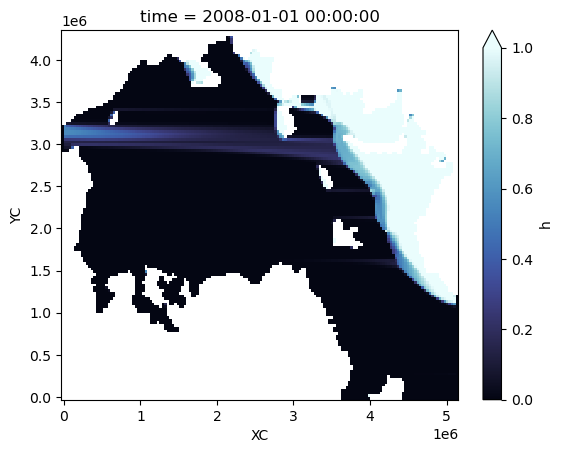

In [9]:
EXP.h.isel(time=-1).plot(cmap=cmo.ice, vmin=0, vmax=1)

Write to netcdf

In [20]:
EXP.to_netcdf(path + "output/nc/EXP" + exp + ".nc")